# Electrification as a second decarbonisation lever

**Question:** Antoine's CART/PRIM finds fossil phase-down as the primary discriminator. But
fossil decline alone can happen two ways: substituting with renewables/electrification, or
substituting with biomass/CCS. Electrification depth (share of final energy delivered as
electricity) is a proxy for the *quality* of the energy transition.

**This notebook:**
1. Compares electrification trajectories across the three outcome groups
2. Tests whether desired-success scenarios have significantly higher electrification *conditional*
   on low fossil use — i.e., electrification as an independent lever on top of fossil phase-down
3. Visualises the 2D space (Fossil 2050 vs Electrification 2050) to reveal the two-lever story

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')

data = pd.read_csv('../antoine_folder/data_for_scenariodiscovery_full.csv')

CAT_DESIRED  = 'Desired (NZ + low CCS)'
CAT_HIGHCCS  = 'NZ but CCS-reliant'
CAT_FAILURE  = 'Failure'
COLORS = {CAT_DESIRED: '#2ca02c', CAT_HIGHCCS: '#ff7f0e', CAT_FAILURE: '#9ecae1'}
ORDER  = [CAT_FAILURE, CAT_HIGHCCS, CAT_DESIRED]

data['category'] = CAT_FAILURE
data.loc[data['success_nz2070'] & ~data['low_ccs_reliance'], 'category'] = CAT_HIGHCCS
data.loc[data['desired_success'], 'category'] = CAT_DESIRED

print(data['category'].value_counts()[ORDER].to_string())

category
Failure                   1102
NZ but CCS-reliant         125
Desired (NZ + low CCS)     372


C:\Users\rb1624\AppData\Local\Temp\ipykernel_29376\3587021675.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['category'] = CAT_FAILURE


## 1. Electrification trajectories by outcome group

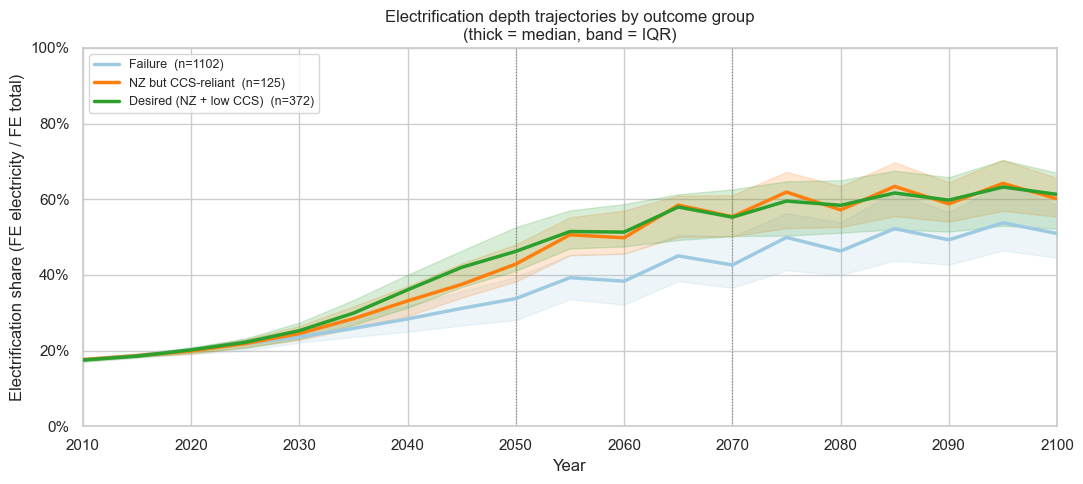

In [2]:
elec_cols = sorted(
    [c for c in data.columns if c.startswith('Electrification|') and c.split('|')[-1].isdigit()],
    key=lambda c: int(c.split('|')[-1])
)
years = [int(c.split('|')[-1]) for c in elec_cols]

fig, ax = plt.subplots(figsize=(11, 5))
for cat in ORDER:
    sub = data[data['category'] == cat][elec_cols]
    col = COLORS[cat]
    n   = len(sub)
    med = sub.median().values
    p25 = sub.quantile(0.25).values
    p75 = sub.quantile(0.75).values
    ax.fill_between(years, p25, p75, color=col, alpha=0.18, zorder=2)
    ax.plot(years, med, color=col, linewidth=2.5,
            label=f'{cat}  (n={n})', zorder=4)

ax.axvline(2050, color='gray', linewidth=0.8, linestyle=':', zorder=1)
ax.axvline(2070, color='gray', linewidth=0.8, linestyle=':', zorder=1)
ax.set_xlim(2010, 2100)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('Year')
ax.set_ylabel('Electrification share (FE electricity / FE total)')
ax.set_title('Electrification depth trajectories by outcome group\n'
             '(thick = median, band = IQR)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('electrification_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Two-lever space: fossil 2050 vs electrification 2050

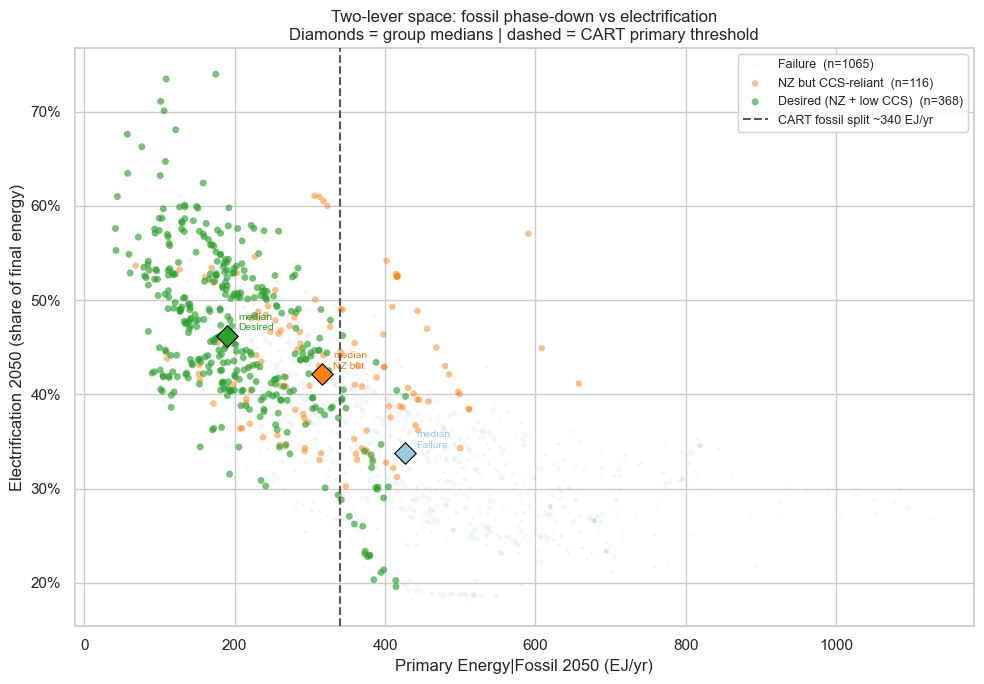

In [3]:
FOSSIL_COL = 'Primary Energy|Fossil|2050'
ELEC_COL   = 'Electrification|2050'

plot_df = data[[FOSSIL_COL, ELEC_COL, 'category']].dropna()

ALPHA = {CAT_FAILURE: 0.08, CAT_HIGHCCS: 0.50, CAT_DESIRED: 0.65}
SIZE  = {CAT_FAILURE: 12,   CAT_HIGHCCS: 22,   CAT_DESIRED: 25}
ZO    = {CAT_FAILURE: 1,    CAT_HIGHCCS: 3,     CAT_DESIRED: 5}

fig, ax = plt.subplots(figsize=(10, 7))
for cat in ORDER:
    sub = plot_df[plot_df['category'] == cat]
    ax.scatter(sub[FOSSIL_COL], sub[ELEC_COL],
               color=COLORS[cat], alpha=ALPHA[cat],
               s=SIZE[cat], label=f'{cat}  (n={len(sub)})',
               zorder=ZO[cat], edgecolors='none')

# Median markers per group
for cat in ORDER:
    sub = plot_df[plot_df['category'] == cat]
    mx, my = sub[FOSSIL_COL].median(), sub[ELEC_COL].median()
    ax.scatter(mx, my, color=COLORS[cat], s=120, marker='D',
               zorder=9, edgecolors='black', linewidth=0.8)
    ax.annotate(f'median\n{cat[:7]}',
                (mx, my), xytext=(8, 4), textcoords='offset points',
                fontsize=7.5, color=COLORS[cat])

# Fossil threshold from CART
ax.axvline(340, color='#555', linewidth=1.5, linestyle='--', zorder=6,
           label='CART fossil split ~340 EJ/yr')

ax.set_xlabel('Primary Energy|Fossil 2050 (EJ/yr)')
ax.set_ylabel('Electrification 2050 (share of final energy)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('Two-lever space: fossil phase-down vs electrification\n'
             'Diamonds = group medians | dashed = CART primary threshold', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('electrification_two_lever_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Is electrification an independent lever? (conditional test)

Among scenarios already below the fossil threshold (≤ 340 EJ/yr), do desired-success
scenarios still show significantly higher electrification?

Scenarios with Fossil 2050 ≤ 340 EJ/yr: 746
  Desired:   336
  CCS-reliant: 62
  Failure:   348


C:\Users\rb1624\AppData\Local\Temp\ipykernel_29376\2989737616.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


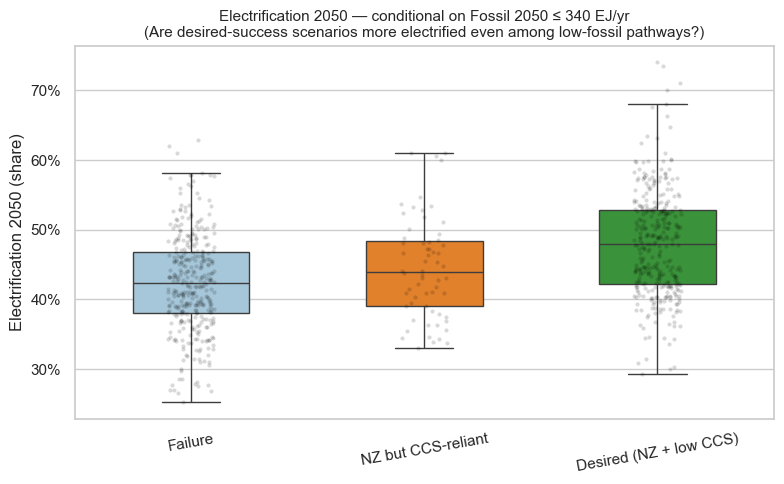


Mann-Whitney U (desired > CCS-reliant electrification, low-fossil region):
  U=13171, p=0.0005
  Desired median:    47.9%
  CCS-reliant median: 44.0%
  → Significant: electrification is an INDEPENDENT lever on top of fossil phase-down


In [4]:
low_fossil = plot_df[plot_df[FOSSIL_COL] <= 340].copy()
print(f'Scenarios with Fossil 2050 ≤ 340 EJ/yr: {len(low_fossil)}')
print(f'  Desired:   {(low_fossil["category"]==CAT_DESIRED).sum()}')
print(f'  CCS-reliant: {(low_fossil["category"]==CAT_HIGHCCS).sum()}')
print(f'  Failure:   {(low_fossil["category"]==CAT_FAILURE).sum()}')

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=low_fossil, x='category', y=ELEC_COL,
    order=[o for o in ORDER if o in low_fossil['category'].unique()],
    palette=COLORS, width=0.5, ax=ax, showfliers=False
)
sns.stripplot(
    data=low_fossil, x='category', y=ELEC_COL,
    order=[o for o in ORDER if o in low_fossil['category'].unique()],
    color='black', alpha=0.15, size=3, jitter=True, ax=ax
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('')
ax.set_ylabel('Electrification 2050 (share)')
ax.set_title('Electrification 2050 — conditional on Fossil 2050 ≤ 340 EJ/yr\n'
             '(Are desired-success scenarios more electrified even among low-fossil pathways?)',
             fontsize=11)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('electrification_conditional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Mann-Whitney test: desired vs high-CCS (both reached NZ) within low-fossil region
desired_elec  = low_fossil.loc[low_fossil['category']==CAT_DESIRED,  ELEC_COL].dropna()
highccs_elec  = low_fossil.loc[low_fossil['category']==CAT_HIGHCCS,  ELEC_COL].dropna()
if len(desired_elec) >= 5 and len(highccs_elec) >= 5:
    u, p = stats.mannwhitneyu(desired_elec, highccs_elec, alternative='greater')
    print(f'\nMann-Whitney U (desired > CCS-reliant electrification, low-fossil region):')
    print(f'  U={u:.0f}, p={p:.4f}')
    print(f'  Desired median:    {desired_elec.median():.1%}')
    print(f'  CCS-reliant median: {highccs_elec.median():.1%}')
    if p < 0.05:
        print('  → Significant: electrification is an INDEPENDENT lever on top of fossil phase-down')
    else:
        print('  → Not significant: electrification alone does not explain the gap')

In [5]:
print('=== Electrification summary ===')
for cat in ORDER:
    sub = data[data['category']==cat][ELEC_COL].dropna()
    print(f'  {cat[:30]:30s}  median={sub.median():.1%}  IQR=[{sub.quantile(0.25):.1%}, {sub.quantile(0.75):.1%}]')

=== Electrification summary ===
  Failure                         median=33.7%  IQR=[28.1%, 39.5%]
  NZ but CCS-reliant              median=42.9%  IQR=[38.2%, 48.1%]
  Desired (NZ + low CCS)          median=46.2%  IQR=[41.1%, 52.6%]
